In [ ]:
!pip install transformers accelerate sentencepiece datasets

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    TrainingArguments,
    Trainer
)


In [ ]:
MODEL_NAME = "google/flan-t5-base"
tok = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [ ]:
import re
import json
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    TrainingArguments,
    Trainer
)
import matplotlib.pyplot as plt


In [ ]:
DATA_XLSX = "/content/Predict_with_this.xlsx"

df = pd.read_excel(DATA_XLSX)

# Keep only needed columns
assert "sentence" in df.columns and "gcode_true" in df.columns, df.columns
df = (
    df[["sentence", "gcode_true"]]
    .rename(columns={"sentence": "instruction", "gcode_true": "output"})
    .dropna()
    .astype(str)
    .drop_duplicates()
    .reset_index(drop=True)
)

# Normalize G-code: spaces + uppercase
def norm_gcode(s: str) -> str:
    s = re.sub(r"\s+", " ", str(s).strip())
    return s.upper()

df["output"] = df["output"].apply(norm_gcode)

# Keep only G28 / G00 / G01
df = df[df["output"].str.match(r"^\s*G\s*(28|0+|0*1)\b")].reset_index(drop=True)

len(df)



481

In [ ]:
TASK_PREFIX = "translate to one safe G-code line (start with G28 or G00 or G01): "

def build_input(inst: str) -> str:
    return TASK_PREFIX + inst.strip()

df["src"] = df["instruction"].apply(build_input)
df["tgt"] = df["output"]


In [ ]:
train_df, test_df = train_test_split(
    df[["src", "tgt"]],
    test_size=0.25,      # 25% test, 75% train
    random_state=42,
    shuffle=True
)

len(train_df), len(test_df)


(360, 121)

In [ ]:
def save_jsonl(path, records):
    with open(path, "w", encoding="utf-8") as f:
        for r in records:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")

train_recs = [{"instruction": r.src, "output": r.tgt} for r in train_df.itertuples(index=False)]
test_recs  = [{"instruction": r.src, "output": r.tgt} for r in test_df.itertuples(index=False)]

save_jsonl("/content/sft_train.jsonl", train_recs)
save_jsonl("/content/sft_test.jsonl",  test_recs)

len(train_recs), len(test_recs)


(360, 121)

In [ ]:
def load_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        return [json.loads(x) for x in f]

train_recs = load_jsonl("/content/sft_train.jsonl")
test_recs  = load_jsonl("/content/sft_test.jsonl")  # will serve also as eval

train_ds = Dataset.from_list(
    [{"src": r["instruction"], "tgt": r["output"]} for r in train_recs]
)
test_ds  = Dataset.from_list(
    [{"src": r["instruction"], "tgt": r["output"]} for r in test_recs]
)


In [ ]:
MODEL_NAME = "google/flan-t5-base"
tok = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

def preprocess(batch):
    model_inputs = tok(batch["src"], max_length=64, truncation=True)
    with tok.as_target_tokenizer():
        labels = tok(batch["tgt"], max_length=32, truncation=True)
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

ds = DatasetDict({
    "train": train_ds.map(preprocess, batched=True, remove_columns=["src", "tgt"]),
    "test":  test_ds.map(preprocess,  batched=True, remove_columns=["src", "tgt"]),
})


Map:   0%|          | 0/360 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4174: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/121 [00:00<?, ? examples/s]

In [ ]:
collator = DataCollatorForSeq2Seq(tok, model=model)

args = TrainingArguments(
    output_dir="/content/flan_t5_gcode_ckpt",
    per_device_train_batch_size=8,
    learning_rate=2e-5,
    num_train_epochs=10,
    logging_steps=50,
    weight_decay=0.01,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=ds["train"],
    eval_dataset=ds["test"],   # using test as eval during training
    tokenizer=tok,
    data_collator=collator,
)

trainer.train()
trainer.save_model("/content/flan_t5_gcode_ckpt")


/tmp/ipython-input-2412232379.py:12: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: sara1376-sami (sara1376-sami-university-of-genoa) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss
50,1.477700
100,0.550600
150,0.362500
200,0.282300
250,0.252500
300,0.242200
350,0.214400
400,0.192100
450,0.194400


In [ ]:
tok = AutoTokenizer.from_pretrained("/content/flan_t5_gcode_ckpt")
model = AutoModelForSeq2SeqLM.from_pretrained("/content/flan_t5_gcode_ckpt")
model.eval()


T5ForConditionalGeneration(
  (shared): Embedding(32128, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseGatedActDense(
              (wi_0): Linear(in_features=768, out_features=2048, bias=False)
              (wi_1): Linear(in_features=768, out_features=2048, bias=False)
              (wo):

In [ ]:
def extract_entities(g):
    return {
        "X": get_val(g, "X"),
        "Z": get_val(g, "Z"),
        "F": get_val(g, "F"),
    }

def entities_match(p, g):
    pe, ge = extract_entities(p), extract_entities(g)
    return pe == ge


In [ ]:
def eval_split(recs):
    preds, golds = [], []

    for r in recs:
        pred = generate_one(r["instruction"])
        preds.append(norm_eval(pred))
        golds.append(norm_eval(r["output"]))

    exact_match = np.mean([p == g for p, g in zip(preds, golds)])

    intent_acc = np.mean([
        intent_of(p) == intent_of(g)
        for p, g in zip(preds, golds)
    ])

    entity_acc = np.mean([
        entities_match(p, g)
        for p, g in zip(preds, golds)
    ])

    joint_acc = np.mean([
        (p == g) and
        (intent_of(p) == intent_of(g)) and
        entities_match(p, g)
        for p, g in zip(preds, golds)
    ])

    validity = np.mean([valid_line(p) for p in preds])

    return {
        "n": len(recs),
        "gcode_exact_match": exact_match,
        "intent_accuracy": intent_acc,
        "entity_accuracy": entity_acc,
        "joint_accuracy": joint_acc,
        "validity_rate": validity
    }


In [ ]:
test_recs = load_jsonl("/content/sft_test.jsonl")
metrics_test = eval_split(test_recs)
metrics_test

{'n': 121,
 'gcode_exact_match': np.float64(0.7107438016528925),
 'intent_accuracy': np.float64(0.9504132231404959),
 'entity_accuracy': np.float64(0.9090909090909091),
 'joint_accuracy': np.float64(0.7107438016528925),
 'validity_rate': np.float64(1.0)}

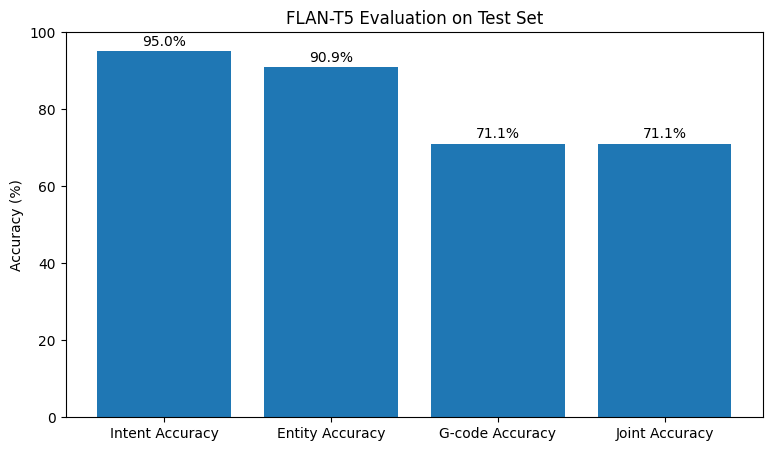

In [ ]:
metrics = {
    "Intent Accuracy": metrics_test["intent_accuracy"] * 100,
    "Entity Accuracy": metrics_test["entity_accuracy"] * 100,
    "G-code Accuracy": metrics_test["gcode_exact_match"] * 100,
    "Joint Accuracy": metrics_test["joint_accuracy"] * 100,
}

plt.figure(figsize=(9,5))
plt.bar(metrics.keys(), metrics.values())
plt.ylabel("Accuracy (%)")
plt.title("FLAN-T5 Evaluation on Test Set")
plt.ylim(0, 100)

for i, v in enumerate(metrics.values()):
    plt.text(i, v + 1.5, f"{v:.1f}%", ha="center")

plt.show()
